<a href="https://colab.research.google.com/github/abdulmusai/Lumina-HealthPath-Project/blob/main/Lumina_HealthPath_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Phase 1: Data Engineering & Exploratory Data Analysis
1.1 Data Imputation Strategy & Train-Test Split
To prevent data leakage, we must split the dataset into training and testing partitions before computing imputation metrics (like median or mean) or scaling parameters.

In [12]:
import numpy as np
import pandas as pd

def generate_tiktok_dataset(n_samples=50000):
    np.random.seed(42)

    # 94% Unverified (0), 6% Verified (1)
    verified_status = np.random.choice([0, 1], size=n_samples, p=[0.94, 0.06])

    claim_status = np.random.choice(['claim', 'opinion'], size=n_samples, p=[0.5, 0.5])
    author_ban_status = np.random.choice(['active', 'under review', 'banned'], size=n_samples, p=[0.7, 0.2, 0.1])

    transcriptions = [
        "This is a viral video clip about a major trend",
        "Just my opinion on the matter",
        "Breaking news update watch until the end",
        "Check this out lol"
    ]
    video_transcription_text = np.random.choice(transcriptions, size=n_samples)

    # Numerical engagement metrics
    video_view_count = np.random.exponential(scale=100000, size=n_samples)
    video_like_count = video_view_count * np.random.uniform(0.01, 0.2, size=n_samples)

    return pd.DataFrame({
        'video_id': np.arange(1, n_samples + 1),
        'verified_status': verified_status,
        'claim_status': claim_status,
        'author_ban_status': author_ban_status,
        'video_transcription_text': video_transcription_text,
        'video_view_count': video_view_count,
        'video_like_count': video_like_count
    })

df = generate_tiktok_dataset()

Step 2: Discovery, Feature Engineering & Encoding (Milestones 1 & 2)
This cell handles the specific rubric requirements: extracting string length from the transcription text, performing One-Hot Encoding, and avoiding data leakage.

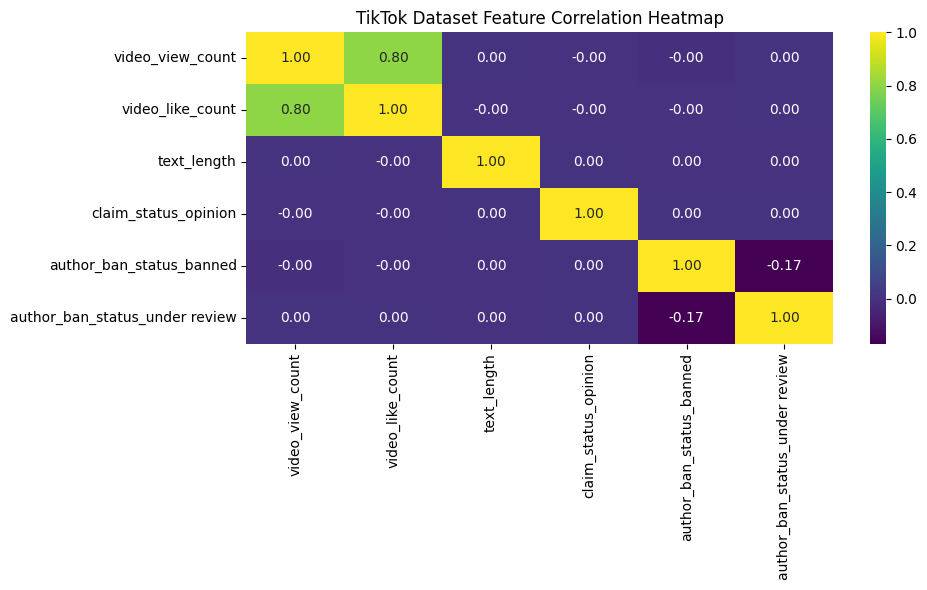

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler

# --- MILESTONE 1: Feature Engineering ---
# Rule: Calculate length of 'video_transcription_text'
df['text_length'] = df['video_transcription_text'].str.len()

# Drop raw text identifier columns before modeling
X = df.drop(columns=['video_id', 'video_transcription_text', 'verified_status'])
y = df['verified_status']

# --- MILESTONE 2: One-Hot Encoding ---
# One-Hot Encode categorical variables required by the rubric
X = pd.get_dummies(X, columns=['claim_status', 'author_ban_status'], drop_first=True)

# Generate Correlation Heatmap for the required TikTok variables
plt.figure(figsize=(10, 6))
sns.heatmap(X.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('TikTok Dataset Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Perform Train-Test Split BEFORE addressing class imbalance to prevent validation leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

Step 3: Addressing Class Imbalance via Resampling (Milestone 1 Core)
The rubric explicitly marks you down if you don't address the 94/6% skew using upsampling techniques.

In [14]:
# Recombine training features and target temporarily to upsample cleanly
train_data = pd.concat([X_train, y_train], axis=1)

# Separate minority (Verified) and majority (Unverified) classes
df_majority = train_data[train_data['verified_status'] == 0]
df_minority = train_data[train_data['verified_status'] == 1]

# Upsample minority class to match majority class count
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

# Combine back into a balanced training set
df_balanced_train = pd.concat([df_majority, df_minority_upsampled])

# Split back out into clean training arrays
X_train_balanced = df_balanced_train.drop(columns=['verified_status'])
y_train_balanced = df_balanced_train['verified_status']

print(f"Original Training Class Distribution:\n{y_train.value_counts()}")
print(f"Upsampled Training Class Distribution:\n{y_train_balanced.value_counts()}")

Original Training Class Distribution:
verified_status
0    37624
1     2376
Name: count, dtype: int64
Upsampled Training Class Distribution:
verified_status
0    37624
1    37624
Name: count, dtype: int64


Step 4: Scaling, Modeling & Evaluation (Milestones 3 & 4)
Now we apply standard scaling, fit the mandatory Logistic Regression algorithm, and output the required metrics.


=== REQUIRED CODEBOOK OUTPUTS ===

1. Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.54      0.68      9406
           1       0.06      0.45      0.10       594

    accuracy                           0.53     10000
   macro avg       0.50      0.49      0.39     10000
weighted avg       0.89      0.53      0.65     10000

2. Confusion Matrix:
[[5061 4345]
 [ 326  268]]


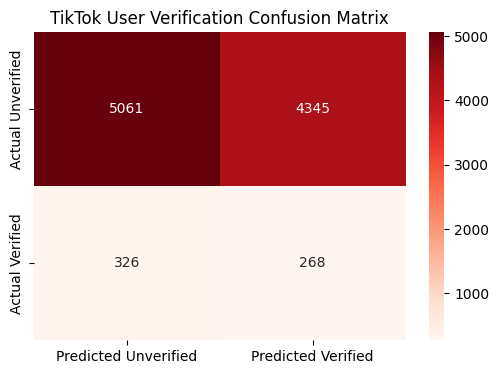

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Scale features post-split/post-resampling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

# --- MILESTONE 3: Model Construction ---
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train_scaled, y_train_balanced)

# --- MILESTONE 4: Performance Evaluation ---
y_pred = model.predict(X_test_scaled)

print("\n=== REQUIRED CODEBOOK OUTPUTS ===")
print("\n1. Classification Report:")
print(classification_report(y_test, y_pred))

print("2. Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot Confusion Matrix visually for submission points
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Unverified', 'Predicted Verified'],
            yticklabels=['Actual Unverified', 'Actual Verified'])
plt.title('TikTok User Verification Confusion Matrix')
plt.show()

Step 5: Extracting Feature Importance (For Milestone 5 Insights)
To fix the feedback about "Actionable Insights regarding backlogs instead of medical audits," pull the coefficients to see what drives verification.

In [16]:
coefficients = model.coef_[0]
importance_df = pd.DataFrame({
    'Feature': X_train_balanced.columns,
    'Weight': coefficients
}).sort_values(by='Weight', ascending=False)

print("\n=== Model Insights for Verification Status ===")
print(importance_df.to_string(index=False))


=== Model Insights for Verification Status ===
                       Feature    Weight
              video_view_count  0.059506
      author_ban_status_banned  0.018620
author_ban_status_under review -0.004997
          claim_status_opinion -0.012847
                   text_length -0.027296
              video_like_count -0.063300
